**The Scenario:** You are tasked with building a basic version of Photoshop using only mathematical operations.

**Creating Arrays & Attributes:**
- You load a provided image (using a library like matplotlib.image to read it into a NumPy array).
- You must inspect .shape, .ndim, and .dtype to understand how the pixels and RGB channels are structured, and create a blank "canvas" using np.zeros().

img: [[[229 218 216]
  [234 223 219]
  [229 222 214]
  ...
  [230 222 211]
  [230 222 211]
  [230 222 211]]

 [[238 231 225]
  [230 221 216]
  [233 224 217]
  ...
  [230 222 211]
  [230 222 211]
  [230 222 211]]

 [[229 220 213]
  [229 220 213]
  [230 220 211]
  ...
  [230 222 211]
  [230 222 211]
  [230 222 211]]

 ...

 [[232 226 214]
  [230 224 212]
  [230 224 212]
  ...
  [169 153 102]
  [175 159 110]
  [176 160 111]]

 [[229 223 211]
  [228 222 210]
  [228 222 210]
  ...
  [171 155 104]
  [176 160 109]
  [176 162 113]]

 [[227 221 209]
  [226 220 208]
  [226 220 208]
  ...
  [174 158 107]
  [174 160 111]
  [178 164 115]]]
img.shape: (636, 560, 3)
img.ndim: 3
img.dtype: uint8
type(img): <class 'numpy.ndarray'>
img.size: 1068480
blank_canvas : [[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  .

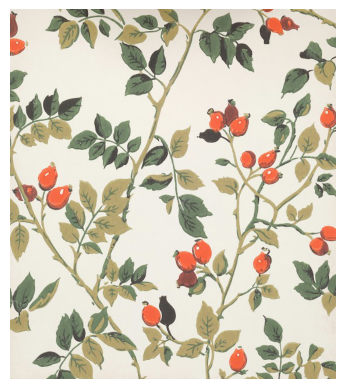

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('photo1.jpg')
print(f"img: {img}")

print(f"img.shape: {img.shape}")
print(f"img.ndim: {img.ndim}")
print(f"img.dtype: {img.dtype}")
print(f"type(img): {type(img)}")
print(f"img.size: {img.size}") # 43074084

blank_canvas = np.zeros((3148, 4561, 3), dtype='uint8')
print(f"blank_canvas : {blank_canvas}")
print(f"blank_canvas.shape : {blank_canvas.shape}")

plt.imshow(img)
plt.axis('off')
plt.show()

Indexing, Slicing & Masking:

- Slicing: Crop the image to focus on a specific subject (e.g., img[100:500, 200:600]).
- Indexing: Isolate only the Red channel of the image.
- Masking: Create a "green screen" effect. Find all pixels where the green value is high and replace them with pixels from a completely different background array.

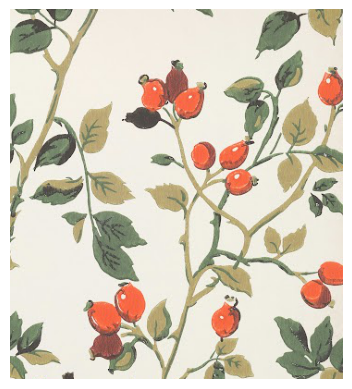

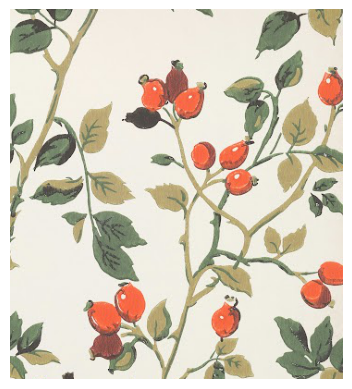

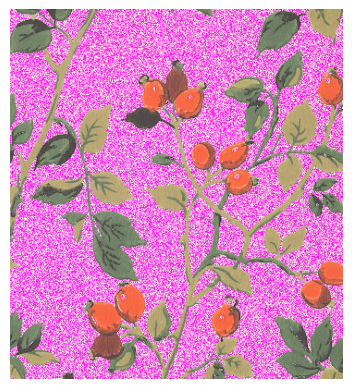

In [13]:
imgv2 = img.copy()

# slicing

imgv2 = imgv2[100:500, 200:600]

# plt.imshow(img)
# plt.axis('off')
# plt.show()

plt.imshow(imgv2)
plt.axis('off')
plt.show()

# indexing
imgv2_red_only = imgv2.copy()

# print(f"imgv2_red_only before isolate: {imgv2_red_only}")

# # isolate red only
# [red, green, blue] <=> '0 for red', '1 for green', '2 for blue'
imgv2_red_only[:, :, 1] = 0
imgv2_red_only[:, :, 2] = 0

# print(f"imgv2_red_only after isolate: {imgv2_red_only}")

# plt.imshow(imgv2_red_only)
# plt.axis('off')
# plt.show()

# masking

imgv2_green_only = imgv2.copy()

# creating the mask (green > 200)
masking_screen = imgv2_green_only[:, :, 1] > 200
masking_screen_value = imgv2_green_only[masking_screen]
random_cropped_green_imgv2 = np.random.randint(0, 256, size=(len(masking_screen_value)), dtype='uint8')

imgv2_green_only[masking_screen, 1] = random_cropped_green_imgv2

# print(f"len of the masking_screen is: {len(masking_screen)}")
# print(f"len of the masking_screen_value is: {len(masking_screen_value)}")

# print(f"masking_screen: {masking_screen}")
# print(f"masking_screen_value: {masking_screen_value}")

plt.imshow(imgv2)
plt.axis('off')
plt.show()

plt.imshow(imgv2_green_only)
plt.axis('off')
plt.show()

**Vectorization, Broadcasting & Ufuncs**:

- Increase the image's brightness by simply adding a scalar value (e.g., img + 50 demonstrating broadcasting).
- Apply a gamma correction or vintage filter using np.power() and np.sqrt() (ufuncs) without writing a single for loop.

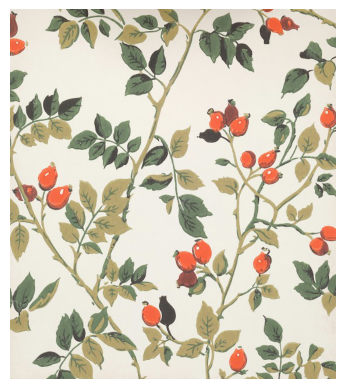

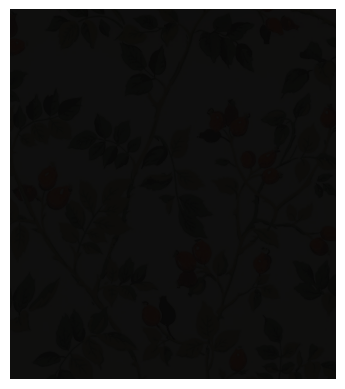

In [8]:
imgv3 = img.copy()

# add 50
# imgv3_temp = imgv3.astype(np.int16)
# imgv3_temp = imgv3_temp + 50
# imgv3_temp = np.clip(imgv3_temp, 0, 255)
# imgv3_temp = imgv3_temp.astype(np.uint8)

# plt.imshow(imgv3)
# plt.axis('off')
# plt.show()

# plt.imshow(imgv3_temp)
# plt.axis('off')
# plt.show()

# power by 2
# imgv3_power = imgv3.astype(np.int16)
# imgv3_power = np.power(imgv3_power, 2)
# imgv3_power = np.clip(imgv3_power, 0, 255)
# imgv3_power = imgv3_power.astype(np.uint8)

# plt.imshow(imgv3)
# plt.axis('off')
# plt.show()

# plt.imshow(imgv3_power)
# plt.axis('off')
# plt.show()

# sqrt
imgv3_sqrt = imgv3.astype(np.int16)
imgv3_sqrt = np.sqrt(imgv3_sqrt)
imgv3_sqrt = np.clip(imgv3_sqrt, 0, 255)
imgv3_sqrt = imgv3_sqrt.astype(np.uint8)

plt.imshow(imgv3)
plt.axis('off')
plt.show()

plt.imshow(imgv3_sqrt)
plt.axis('off')
plt.show()

**Math & Stats**:

- Find the brightest and darkest pixels in the image (np.max, np.min).
- Calculate the average pixel intensity of the image to determine if it is "overexposed" or “underexposed” (np.mean across specific axes).

In [10]:
imgv4 = img.copy()

# math
imgv4_max = np.max(img)
imgv4_min = np.min(img)
print(f"Max pixel: {imgv4_max}")
print(f"Min pixel: {imgv4_min}")
# Stats
imgv4_average = np.mean(img)
print(f"Average intensity: {imgv4_average}")

mean_rgb = np.mean(img, axis=(0, 1))
print(f"Mane RPG: {mean_rgb}")

Max pixel: 255
Min pixel: 0
Average intensity: 193.22221379904164
Mane RPG: [204.73902179 197.26927785 177.65834176]
